# CNN and Image Classification Exercises

## Exercise 1: Cross-Correlation Operation

Perform the cross-correlation operation between an input tensor with 3 input channels and the following kernel:

**Kernel (3 channels):**
- Channel 1: `[[0, 1], [2, 3]]`
- Channel 2: `[[1, 2], [3, 4]]`
- Channel 3: `[[7, 2], [3, 5]]`

**Requirements:**
- Apply cross-correlation operation
- Handle 3 input channels
- Use the provided 2×2 kernels for each channel

---



In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

In [2]:
X = torch.tensor(
    [
        [
            [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
            [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]],
            [[1.0, 2.0, 2.0], [4.0, 1.0, 6.0], [7.0, 8.0, 9.0]],
        ]
    ]
)

K = torch.tensor(
    [[[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]], [[7.0, 2.0], [3.0, 5.0]]]]
)

F.conv2d(X, K)

tensor([[[[ 84., 123.],
          [195., 208.]]]])

## Exercise 2: LeNet Classification on SVHN Dataset

Classify the SVHN (Street View House Numbers) dataset using the LeNet model.

**Dataset Specifications:**
- Image size: 32×32 pixels
- Number of classes: 10
- Total training images: 73,257
- Total testing images: 26,032

**Training Configuration:**
- Training images: 43,257
- Validation images: 30,000
- Learning rate: 0.5

**Tasks:**
- Implement LeNet architecture
- Split the training dataset as specified
- Train the model with the given parameters
- Evaluate on test set

---



In [5]:
import torch

def load_data(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split='train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split='test', transform=trans, download=True)

    # Split training data: 43,257 for training, 30,000 for validation
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(42))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

train_iter, val_iter, test_iter = load_data(32)


In [6]:
net = nn.Sequential(
    nn.Conv2d(3, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 6 * 6, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))
net

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Sigmoid()
  (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): Sigmoid()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=576, out_features=120, bias=True)
  (8): Sigmoid()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): Sigmoid()
  (11): Linear(in_features=84, out_features=10, bias=True)
)

In [8]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [21]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [10]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [11]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [12]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [13]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [23]:
lr, num_epoch = 0.5, 10
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epoch, lr, try_gpu()) #2 min

Training on cpu
Epoch 1, Train loss 2.25, Train accuracy 18.53, Validation loss 2.24, Validation accuracy 18.97
Epoch 2, Train loss 2.24, Train accuracy 18.73, Validation loss 2.24, Validation accuracy 18.97
Epoch 3, Train loss 2.24, Train accuracy 18.83, Validation loss 2.24, Validation accuracy 18.97
Epoch 4, Train loss 2.24, Train accuracy 18.80, Validation loss 2.24, Validation accuracy 18.97
Epoch 5, Train loss 2.24, Train accuracy 18.77, Validation loss 2.24, Validation accuracy 18.97
Epoch 6, Train loss 2.24, Train accuracy 18.83, Validation loss 2.24, Validation accuracy 18.97
Epoch 7, Train loss 2.24, Train accuracy 18.78, Validation loss 2.24, Validation accuracy 18.97
Epoch 8, Train loss 2.24, Train accuracy 18.80, Validation loss 2.24, Validation accuracy 18.97
Epoch 9, Train loss 2.24, Train accuracy 18.79, Validation loss 2.24, Validation accuracy 18.97
Epoch 10, Train loss 2.24, Train accuracy 18.79, Validation loss 2.24, Validation accuracy 14.21
Test loss 2.23, Test ac

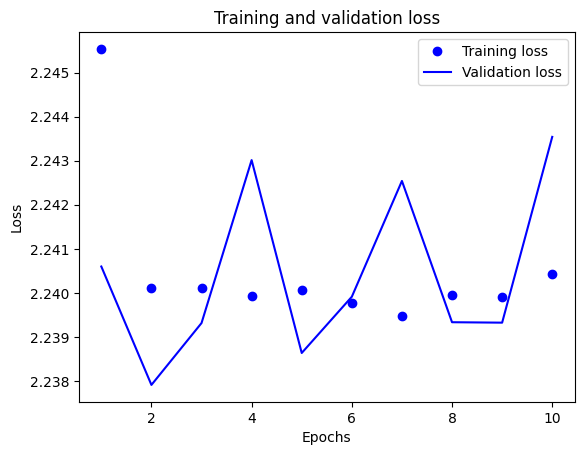

In [24]:
plot_loss(train_loss_all, val_loss_all)

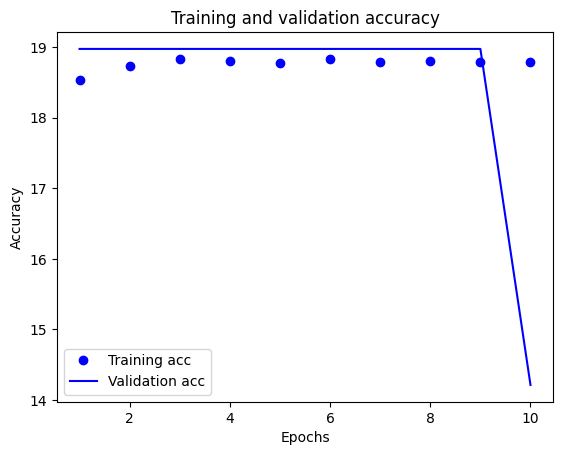

In [25]:
plot_accuracy(train_acc_all, val_acc_all)

## Exercise 3: Custom CNN Architecture on SVHN Dataset

Classify the SVHN dataset using a custom convolutional neural network architecture with residual-style connections.

**Dataset Split:**
- Training images: 43,257
- Validation images: 30,000

**Training Hyperparameters:**
- Number of epochs: 5
- Learning rate: 0.05
- Batch size: 256

**Architecture Requirements:**

### Convolutional Block Structure
The Convolutional Block should contain:
1. **First path:**
   - Conv2d: 64 output channels, 3×3 kernel, with ReLU activation

2. **Second path:**
   - Conv2d: 32 output channels, 3×3 kernel
   - BatchNorm2d
   - ReLU activation
   - Conv2d: 64 output channels, 3×3 kernel
   - BatchNorm2d
   - ReLU activation

3. **Add operation:** Element-wise addition of both paths

### Full Network Architecture
- Input layer (32×32×3 images)
- Convolutional Block (as defined above)
- Flatten layer
- Linear layer: 10 output units (for 10 classes)

**Implementation Notes:**
- Use padding if necessary to maintain spatial dimensions
- Implement a separate class for the Convolutional Block
- Conv2d format: `Conv2d(in_channels, out_channels, kernel_size)`
- Ensure both paths in the Convolutional Block produce the same spatial dimensions for the Add operation

In [5]:
#3
import torch

def load_data_svhn(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    svhn_train = torchvision.datasets.SVHN(
        root="../data", split='train', transform=trans, download=True)
    svhn_test = torchvision.datasets.SVHN(
        root="../data", split='test', transform=trans, download=True)

    # Split training data: 43,257 for training, 30,000 for validation
    svhn_train, svhn_val = torch.utils.data.random_split(svhn_train, [43257, 30000],
                                                           generator=torch.Generator().manual_seed(33))
    return (torch.utils.data.DataLoader(svhn_train, batch_size, shuffle=True,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_val, batch_size, shuffle=False,
                            num_workers=2),
            torch.utils.data.DataLoader(svhn_test, batch_size, shuffle=False,
                            num_workers=2))

In [3]:
class ConvBlock(nn.Module):
    """The Residual block of ResNet."""
    def __init__(self):
        super().__init__()

        self.left = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64,kernel_size=3,padding = 1),
            nn.ReLU()
        )

        self.right = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3,padding = 1)
        )

        self.right2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

    def forward(self, X):
        x = self.left(X)
        y = self.right(X)
        y = self.right2(y)
        return torch.add(x,y)


In [19]:
net = nn.Sequential(ConvBlock(),nn.Flatten(),nn.Linear(64 * 32 * 32,10))


In [8]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples  * 100

In [23]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    
    print(X.shape)
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples  * 100

In [10]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('Training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(f'Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}')
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f'Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}')

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [11]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [12]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_all, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [13]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, val_acc_all, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [24]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_svhn(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()) #2 min

Training on cpu
torch.Size([249, 3, 32, 32])
Epoch 1, Train loss 4.86, Train accuracy 19.25, Validation loss 2.29, Validation accuracy 14.88
torch.Size([249, 3, 32, 32])
Epoch 2, Train loss 1.99, Train accuracy 32.59, Validation loss 1.79, Validation accuracy 43.33
torch.Size([249, 3, 32, 32])
Epoch 3, Train loss 1.61, Train accuracy 48.17, Validation loss 1.45, Validation accuracy 52.88
torch.Size([249, 3, 32, 32])
Epoch 4, Train loss 1.26, Train accuracy 61.37, Validation loss 1.17, Validation accuracy 63.83
torch.Size([249, 3, 32, 32])
Epoch 5, Train loss 1.01, Train accuracy 69.91, Validation loss 1.01, Validation accuracy 68.95
Test loss 1.11, Test accuracy 66.86


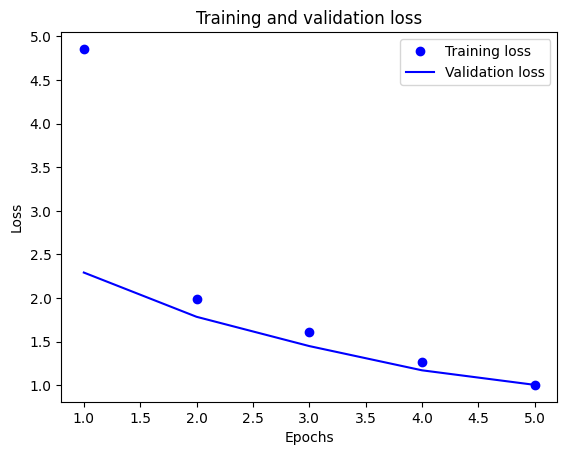

In [25]:
plot_loss(train_loss_all, val_loss_all)

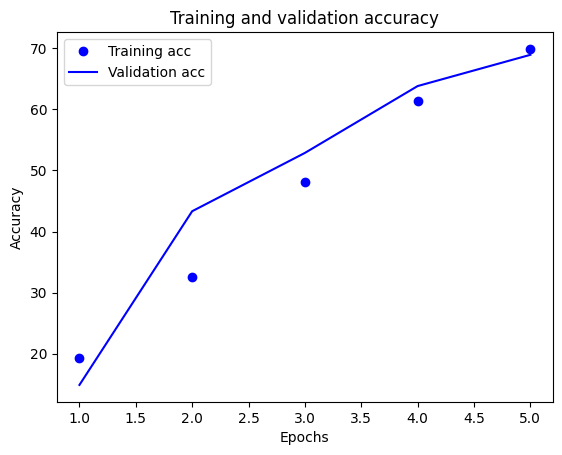

In [26]:
plot_accuracy(train_acc_all, val_acc_all)